<a href="https://colab.research.google.com/github/lexmar07/Deep-Legendre-Transform/blob/main/NIPS_ConvexConjugates_approximate_inverse_sampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Convex conjugation plays an important role in convex duality theory.
For a subset $C \subseteq  \mathbb{R} ^d$, let us denote by
$\delta_C \colon \mathbb{R} ^d \to \mathbb{R}  \cup \{+\infty\}$ the indicator function
given by
$$
\delta_C(x) := \begin{cases} 0 & \mbox{ if } x \in C\\
+ \infty & \mbox{ if } x \notin C.
\end{cases}
$$
For a function $f \colon \mathbb{R} ^d \to \mathbb{R} \cup \{+ \infty\}$, we denote by
$f_C^* \colon  \mathbb{R}  \cup \{+ \infty\}$ the convex conjugate of $f + \delta_C$ given by
$$
f_C^*(y) := \sup_{x \in C} { \langle x , y\rangle - f(x) }.
$$


In the special case, where $f \colon C \to R$ is a differentiable convex function
on an open convex set $C \subseteq R^d$, one has  
$$
f^*(y) = \langle(\nabla f)^{-1}(y), y\rangle  - f((\nabla f)^{-1}(y))
$$
for all $y \in D = \nabla f(C).$

The right side of the equation is called Legendre transform.


## Sampling in the gradient space from a desired distribution.

Since our goal is to approximate $f^*(y)$, in some cases, it might be beneficial to train the model on samples $\{y_i\}$ that have some desired distribution $\nu$. For example, $\nu$ can be a uniform distribution on some compact subset $K$ of $D$. However, if we sample $d$-dimensional $x$ uniformly, then the gradient $\nabla f(x)$ will (generally) not have a $d$-dimensional uniform distribution.
The desired $x$-sample can be obtained as $\{(\nabla f)^{-1}(z)\}$, where $(\nabla f)^{-1}(z)$ is some element from the preimage, and $z$ is sampled according to $\nu$ on $K$.
In some cases, the inverse mapping $(\nabla f)^{-1}$ exists and can be found analytically; however, generally, we have to rely on approximations.

To address this problem, we introduce the concept which we call \textit{the approximate inverse mapping}\footnote{We believe this unsupervised learning approach might be useful across various disciplines where computing inverse mappings is required.}. The idea is as follows:
Let $\Psi:\mathbb{R}^d \to \mathbb{R}^d$ be some mapping. We can learn an "autoencoder type" architecture
$$
x \xrightarrow{\mathfrak{e}} \Psi(x) \xrightarrow{\mathfrak{d}} x,
$$
where the encoder $\mathfrak{e}$ is set equal to $\Psi$. The decoder part, $\mathfrak{d}: \psi \mapsto x$, will provide an approximate inverse to the mapping $\Psi$ if $\Psi$ is invertible, and an element from the preimage otherwise. As a result, one can sample from the distribution $\nu$ in the $\{\psi\}$ space so that $\mathfrak{d}(\psi)$ generates $\{x\}$-sample, which will (approximately) have the desired property.




## Some examples:


* Quadratic
$f(x) = \frac12 x^T P x +b^Tx+c$, where $P$ is a positive semi-definite matrix, $x\in \mathbb{R}^n.$ Then conjugate is

$$f^*(y) = \frac12(y-b)^TP^{-1}(y-b) - c$$
(if $P$ is positive-definite, otherwise use pseudoinverse $P^\dagger = (AA^T)^{-1}A $).



* Quadratic over linear
$f(x, y) =  x^T P x/y$, where $(x, y)\in \mathbb{R}^n\times \mathbb{R}_{++}$


$$???$$





* Negative logarithm

$f(x) = -\sum\limits_{i=1}^n \log(x_i)$

$$f^*(y) = - \sum\limits_{i=1}^n\log(-y_i) -n$$

* Negative entropy
$f(x) = \sum_i x_i\log(x_i), x\in \mathbb{R}^n_+$

$f^*(y) = \sum\limits_{i=1}^ne^{y_i}-1$

Libraries: JAX.

In [ ]:
# !pip install optax

In [ ]:
import numpy as np
import jax
import jax.numpy as jnp
from jax import random, vmap, lax
from jax.tree_util import tree_leaves
# import haiku as hk
import optax
import matplotlib.pyplot as plt
import yaml
import os
import time
import sys
import json
from scipy.io import savemat
from tqdm import tqdm
from collections import namedtuple
from functools import partial
from typing import Callable, Any, List

# Flax library imports
from flax import linen as nn
from flax.training import train_state



In [ ]:
base_path = "/content/drive/MyDrive/ETH/Convex_conjugates/experiments_with_ICNN_5"
 # results of experiments with ICNN that use nonlinear transform to ensure convexity
sys.path.append(base_path)

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Functions to play with:

In [ ]:
# Primal QUADRATIC:
def square(x):
    return jnp.reshape(jnp.sum(x*x, -1), ())
# Dual:
square_star_true = lambda x: jnp.sum(x*x, -1) / 4

##################################
# Primal QUADRATIC OVER LINEAR (dividing by the last component of x)
def quad_over_lin(x):
    numerator = jnp.sum(x[:-1]**2)
    denominator = x[-1]
    return numerator / denominator
# Dual
# ?

#########################
# Primal NEGATIVE-ENTROPY
def negative_entropy(x):
    return jnp.reshape(jnp.sum(x * jnp.log(x), -1), ())
# Dual
negative_entropy_star_true = lambda x: jnp.sum(jnp.exp(x - 1), -1)


##########################
# Primal Negative Logarithm
def negative_logarithm(x):
    return -jnp.sum(jnp.log(x), axis=-1)

# Dual of the Negative Logarithm
def negative_logarithm_star_true(y):
    return -jnp.sum(jnp.log(-y), axis=-1) - y.shape[-1]



In [ ]:
# Identity function to ensure non-negativity (scales the input by beta)
def G_ID(v, beta):
    return beta * v

# Square function to ensure non-negativity (squares the input scaled by beta)
def G_SQUARE(v, beta):
    return jnp.square(beta * v)


In [ ]:
class NonNegativeDense(nn.Module):
    features: int
    use_bias: bool = True
    dtype: Any = None
    kernel_init: Callable = nn.initializers.lecun_normal()
    bias_init: Callable = nn.initializers.zeros
    pre_transform: Callable = jnp.square # Optional pre-transformation

    @nn.compact
    def __call__(self, inputs):
        kernel_shape = (inputs.shape[-1], self.features)
        kernel = self.param('kernel', self.kernel_init, kernel_shape)
        # if self.pre_transform:
        kernel = self.pre_transform(kernel)  # Apply pre-transformation if any
         # Squaring the kernel to ensure non-negative weights
        y = jnp.dot(inputs, kernel)
        if self.use_bias:
            bias = self.param('bias', self.bias_init, (self.features,))
            y += bias
        return y

class ConvexNN(nn.Module):
    layer_widths: List[int]
    activation: Callable = nn.relu  # Default activation; adjust as needed

    @nn.compact
    def __call__(self, x):
        # Adjust to handle specific transformations for the first and last layers if needed
        for i, width in enumerate(self.layer_widths):
            # Use NonNegativeDense with optional pre_transform for the last layer
            if i == 0:  # First layer, using standard nn.Dense
                x = nn.Dense(features=width)(x)
            else:  # Intermediate layers with NonNegativeDense without pre_transform
                x = NonNegativeDense(features=width)(x)
            x = self.activation(x)

        # Final output layer, assuming a single output unit for simplicity
        x = NonNegativeDense(features=1)(x)  # Adjust if different behavior is desired
        return x


# Configuration Parameters

- **experiment_name**: A string used to uniquely identify and track the experiment.
- **description**: A string describing the purpose or details of the experiment.
- **dim**: An integer representing the dimensionality of the input space.
- **layer_widths**: A list of integers specifying the number of units in each layer of the neural network.
- **num_epochs**: An integer representing the number of epochs to train the model.
- **batch_size**: An integer specifying the size of each training batch.
- **steps**: An integer representing the number of steps the model takes per batch, relevant when mini-batch optimization is used (i.e., when `use_grid` is False).
- **start**: A float or list of floats representing the start point(s) of the rectangular domain for the primal variables \( x \).
- **end**: A float or list of floats representing the end point(s) of the rectangular domain for the primal variables \( x \).
- **convrg_eps**: A float specifying the convergence threshold epsilon for stopping the training.
- **learning_rate**: A float representing the learning rate for the optimizer.
- **l2_regularization_coefficient**: A float for the L2 regularization term to prevent overfitting.
- **N_ae**: An integer specifying the number of epochs for pretraining an autoencoder, if applicable.
- **v_init_fn**: A callable function for initializing the parameters. For instance, it could be a function that generates random values within a certain range.
- **minval**: A float or list of floats indicating the minimum value(s) for the gradient domain, corresponding to the dual variables \( y \).
- **maxval**: A float or list of floats indicating the maximum value(s) for the gradient domain, corresponding to the dual variables \( y \).
- **y_func**: A callable function defining the behavior or computation of the dual variables \( y \).
- **y_func_star**: A callable function representing the true conjugate of \( y \).

## Domain Explanation

- **Primal Domain (`start` to `end`)**: The domain for the primal variables \( x \) is defined as \([start, end]^d\).
- **Dual Domain (`minval` to `maxval`)**: The domain for the dual variables \( y \) is defined as \([minval, maxval]^d\).

The correct transformation between the domains is $\nabla f: H \to K$  and $\nabla^{-1} f: K\to H$ realized below with approximate inverse mappings.

In [ ]:
LEARNING_RATE = 3e-4
ALPHA = 1e-8 #

Config = namedtuple("Config",
                    [
                     "experiment_name",        # Name of the experiment for tracking purposes
                     "description",            # Description of the experiment
                     "dim",                    # Dimensionality of the input space
                     "layer_widths",           # Widths of each layer in the neural network
                     "num_epochs",             # Number of epochs for training
                     "batch_size",             # Batch size for training
                     "steps",                  # Number of steps per batch (useful if use_grid is False)
                     "start",                  # Start point of the primal domain (rectangular domain start)
                     "end",                    # End point of the primal domain (rectangular domain end)
                     "convrg_eps",             # Convergence epsilon for stopping criterion
                    "ae_convrg_eps",             # Convergence epsilon for stopping criterion for ae
                     "learning_rate",          # Starting value of the learning rate for the optimizer
                     "N_ae",                   # Number of epochs for autoencoder pretraining
                     "v_init_fn",              # Initialization function for the parameters
                     "minval",                 # Minimum value for the gradient domain (dual domain start)
                     "maxval",                 # Maximum value for the gradient domain (dual domain end)
                     "f_func",                 # Function definition for y (dual variables)
                     "f_func_star",             # True function conjugate for y
                     "train_sampling",         # use inverse sampling for train
                     "test_sampling"           # use inverse sampling for test
                    ])




In [ ]:
# Map the string names to the actual functions
function_mapping = {
    "G_SQUARE": G_SQUARE,# g_fn
    "G_ID": G_ID,# g_fn
    "square": square,
    "square_star_true" : square_star_true,
    "negative_entropy": negative_entropy,
    "negative_entropy_star_true" : negative_entropy_star_true,
    "negative_logarithm": negative_logarithm,
    "negative_logarithm_star_true": negative_logarithm_star_true,
    # Add other functions...
}


# Some saving/loading utils:

In [ ]:
def save_statistics(statistics, path_to_save, filename):
    # Convert JAX arrays to NumPy arrays, NumPy arrays to lists, and float32 to float
    serializable_stats = {}
    for k, v in statistics.items():
        if isinstance(v, (jnp.ndarray, np.ndarray)):
            v = jax.device_get(v).tolist()
        elif isinstance(v, np.float32):
            v = float(v)
        serializable_stats[k] = v

    print("Statistics:")
    for key, value in statistics.items():
        print(f"  {key}: {value}")

    full_path = os.path.join(path_to_save, filename)
    with open(full_path, 'w') as file:
        json.dump(serializable_stats, file)


In [ ]:
def save_config_to_yaml(config, path):
    with open(path, 'w') as file:
        yaml.dump(dict(config._asdict()), file)

## Some plotting/statistics utils:

In [ ]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

def plot_results(d, eval_grad_f_x, preds, vmap_f_star_true, state, const_val, Loss):
    """
    Plots evaluation results and calculates residuals.

    Args:
        d (int): Dimensionality of the input space.
        eval_grad_f_x (array): Evaluated gradient values.
        preds (array): Predictions from the model.
        vmap_f_star_true (callable): Function to compute true conjugate values.
        state (train_state.TrainState): Training state containing model parameters.
        const_val (float): Constant value for plotting higher dimensions.
        Loss (list): List of loss values over epochs.
    """
    # dpi = 300  # Set DPI for higher quality images
    dpi = 100

    if d == 1:
        # Sort and plot for 1D
        eval_grad_f_x = np.squeeze(eval_grad_f_x)
        indices = np.argsort(eval_grad_f_x)
        eval_grad_f_x, preds = eval_grad_f_x[indices], preds.flatten()[indices].reshape(-1, 1)
        plt.figure(dpi=dpi)
        plt.plot(eval_grad_f_x, preds, lw=3, label='Predictions')
        plt.plot(eval_grad_f_x, vmap_f_star_true(eval_grad_f_x.reshape(-1, 1)), lw=1, label='True Conjugate')
        plt.xlabel('eval_grad_f_x')
        plt.ylabel('Function Values')
        plt.title('Sorted Points and Function Values')
        plt.legend()
        plt.grid(True)
        plt.show()

        # Calculate and print RMSE (residual)
        accuracy = 1 / np.sqrt(eval_grad_f_x.shape[0]) * jnp.linalg.norm(preds.reshape(-1, 1) - vmap_f_star_true(eval_grad_f_x).reshape(-1, 1))
        print("Residual:", accuracy)

    if d >= 2:
        # Scatter plot for first two components in 2D+
        start = jnp.min(eval_grad_f_x)
        end = jnp.max(eval_grad_f_x)
        plt.figure(dpi=dpi)
        plt.scatter(eval_grad_f_x[:, 0], eval_grad_f_x[:, 1], c='red', marker='o')
        plt.xlabel('Component 0 of eval_grad_f_x')
        plt.ylabel('Component 1 of eval_grad_f_x')
        plt.title('Scatter Plot of First Two Components of eval_grad_f_x')
        plt.grid(True)
        plt.show()

        def generate_1D_line_in_dD_space(axis, const_val, start, end, num_points=100, d=d):
            x = jnp.linspace(start, end, num_points)
            line_dD = jnp.ones((num_points, d)) * const_val
            line_dD = line_dD.at[:, axis].set(x)
            return line_dD

        def calculate_and_plot(axis, const_val):
            line_dD = generate_1D_line_in_dD_space(axis, const_val, start, end)
            f_x = state.apply_fn({'params': state.params}, line_dD)
            f_star_true_x = vmap_f_star_true(line_dD)

            # Calculate and print RMSE along the axis
            accuracy = 1 / np.sqrt(line_dD.shape[0]) * jnp.linalg.norm(f_x.reshape(-1, 1) - f_star_true_x.reshape(-1, 1))
            print("Residual along axis {} @ value = {}: {}".format(axis, const_val, accuracy))

            plt.figure(dpi=dpi)
            plt.plot(line_dD[:, axis], f_x, label='f(x)')
            plt.plot(line_dD[:, axis], f_star_true_x, label='True Conjugate')
            plt.title('Numerical and Analytical Conjugate along axis {}'.format(axis))
            plt.legend()
            plt.grid(True)
            plt.show()

        calculate_and_plot(axis=0, const_val=const_val)
        calculate_and_plot(axis=1, const_val=const_val)

    # Plot training loss over epochs
    plt.figure(dpi=dpi)
    plt.plot(Loss, label='Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training Loss Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
def descriptive_statistics(data, name="Data"):
    """Returns descriptive statistics for the given data as a dictionary."""
    data = np.array(data)
    mean = np.mean(data, axis=0)
    std_dev = np.std(data, axis=0)
    minimum = np.min(data, axis=0)
    maximum = np.max(data, axis=0)
    shape = data.shape

    statistics = {
        "name": name,
        "shape": shape,
        "mean": mean,
        "std_dev": std_dev,
        "min": minimum,
        "max": maximum
    }

    return statistics


In [ ]:
def calculate_statistics(eval_batch_x, eval_grad_f_x, preds, vmap_f_star_true, loss_value):
    """
    Calculate various statistics for evaluating the model's performance.

    Args:
        eval_batch_x (array): Batch of evaluation input data.
        eval_grad_f_x (array): Batch of gradient values.
        preds (array): Predictions from the model.
        vmap_f_star_true (callable): Function to compute true conjugate values.
        loss_value (float): The loss value from the model.

    Returns:
        acc (float): Root Mean Squared Error (RMSE) between predictions and true values, excluding infinities.
        max_acc (float): Maximum error between predictions and true values, excluding infinities.
        res (float): Square root of the loss value.
        mre (float): Mean Relative Error (MRE) between predictions and true values, excluding infinities.
    """
    # Calculate true conjugate values
    f_star_values = vmap_f_star_true(eval_grad_f_x)

    # Identify points where vmap_f_star_true gives infinity
    is_finite = jnp.isfinite(f_star_values)

    # Apply the mask to filter out infinite points
    finite_preds = preds[is_finite]
    finite_f_star_values = f_star_values[is_finite]

    # Reshape for calculation
    finite_preds_reshaped = finite_preds.reshape(-1, 1)
    finite_f_star_values_reshaped = finite_f_star_values.reshape(-1, 1)

    # Calculate RMSE excluding infinite points
    acc = 1 / np.sqrt(finite_preds_reshaped.shape[0]) * jnp.linalg.norm(finite_preds_reshaped - finite_f_star_values_reshaped)

    # Calculate maximum error excluding infinite points
    max_acc = jnp.max(jnp.abs(finite_preds_reshaped - finite_f_star_values_reshaped))

    # Calculate Mean Relative Error (MRE), avoiding division by zero
    relative_errors = jnp.where(finite_f_star_values_reshaped != 0,
                                jnp.abs((finite_preds_reshaped - finite_f_star_values_reshaped) / finite_f_star_values_reshaped),
                                0)
    mre = jnp.mean(relative_errors)

    # Calculate square root of the loss value
    res = np.sqrt(loss_value)

    return acc, max_acc, res, mre


## RUN **SINGLE** EXPERIMENT

In [ ]:

cfg = Config(
    experiment_name = "test",               # Name of the experiment for tracking purposes
    description = "test experiment",        # Description of the experiment
    dim = 2,                               # Dimensionality of the input space
    layer_widths = (128, 64, 64),           # Widths of each layer in the neural network
    num_epochs = 100000,                   # Number of epochs for training
    N_ae = 20000,                           # Number of epochs for autoencoder pretraining
    batch_size = 3200,                      # Batch size for training # YOU CAN USE MORE!!!
    steps = 2,                              # Number of steps per batch (useful if use_grid is False)
    start = 0.001,                              # Start point of the primal domain (rectangular domain start point)
    end = 0.01,                                # End point of the primal domain (rectangular domain end point)
    minval = None,                             # Minimum value for the gradient domain (dual domain start)
    maxval = None,                            # Maximum value for the gradient domain (dual domain end)
    convrg_eps = 1e-5,                      # Convergence epsilon for stopping criterion
    ae_convrg_eps = 1e-7,                   #  Convergence epsilon for  ae stopping
    learning_rate = 3e-3,                   # Learning rate for the optimizer
    v_init_fn = "V_INIT_Uniform",           # Initialization function for the parameters
    f_func = "negative_logarithm",            # Function definition for f (dual variables)
    f_func_star = "negative_logarithm_star_true", # True function conjugate for f*
    train_sampling = True, # use inverse sampling for train
    test_sampling = True, # use inverse sampling for test
)

# path_to_results_and_cfgs = os.path.join(base_path, "Experiment_test")

# # Path to the YAML file
# config_path = os.path.join(path_to_results_and_cfgs, 'config.yaml')

# # Save the config to the YAML file
# save_config_to_yaml(cfg, config_path)

## JAX tricks:

We vmap all the funcitons for efficient computing.

In [ ]:
initial_key = jax.random.PRNGKey(0)

f = function_mapping[cfg.f_func]
f_star_true =  function_mapping[cfg.f_func_star]

# Wrapping the modified objective function with grad, jit, and vmap
grad_f_fn = jax.grad(f, argnums=0)
grad_f = jax.jit(grad_f_fn)

# Vectorization for processing batches of inputs "vmap_f_epsilon"
vmap_grad_f = vmap(grad_f, in_axes = 0)
vmap_f = vmap(f, in_axes = 0)
vmap_f_star_true = vmap(f_star_true, in_axes = 0)


## Approximate inverse mapping

Since our goal is to approximate $f^*(y)$, in some cases, it might be beneficial to train the model on samples $\{y_i\}$ that have some desired distribution $\nu$. For example, $\nu$ can be
a uniform distribution on some compact subset $K$ of~$D$. However, if we sample $d$-dimensional $x$ uniformly, then the gradient $\nabla f(x)$ will (generally) not have a $d$-dimensional uniform distribution.

The desired $x$-sample can be obtained as $\{(\nabla f)^{-1}(z)\}, $ where $(\nabla f)^{-1}(z)$ is some element from the preimage, and $z$ is sampled according to $\nu$ on $K$, see Fig. \ref{fig:measure_pushforward}. In some cases, the inverse mapping $(\nabla f)^{-1}$ exists and can be found analytically; however, generally, we have to rely on approximations.


To address this problem, we introduce the concept which we call \textit{the approximate inverse mapping}. The idea is as follows:
Let $\Psi:\mathbb{R}^d \to \mathbb{R}^d$ be some mapping.

1. We can learn $\Psi^{-1}$ (preimage) as decoder in an "autoencoder type" architecture:
$$
x \xrightarrow{\mathfrak{e}} \Psi(x) \xrightarrow{\mathfrak{d}} x
,$$
where the encoder $\mathfrak{e}$ is set equal to $\Psi$. The decoder part, $\mathfrak{d}: \psi \mapsto x$, will provide an approximate inverse to the mapping $\Psi$ if $\Psi$ is invertible, and an element from the preimage otherwise.

2. We can learn $\Psi^{-1}$ (preimage) as  encoder in an "autoencoder type" architecture:
$$
y \xrightarrow{\mathfrak{e}} \Psi^{-1}(y) \xrightarrow{\mathfrak{d}} y
,$$
where the decoder $\mathfrak{d}$ is set equal to $\Psi$. The encoder part, $\mathfrak{e}: y \mapsto x$, will provide an approximate inverse to the mapping $\Psi$ if $\Psi$ is invertible, and an element from the preimage otherwise.

If domain of $\Psi$  is known to be large  (totally safe option is the whole $\mathbb{R}^d$, otherwise one needs  sample with rejection) then we can safely use the second variant, which is generally more convenient. Otherwise, 1. is safer option.

As a result, one can sample from the distribution $\nu$ in the $\{\psi\}$ space so that $\mathfrak{d}(\psi)$ generates $\{x\}$-samples, which will (approximately) have the desired property.

We use Variant 1. here.



In [ ]:
# # Example training loop setup
n_samples = cfg.batch_size * 10
batch_size = cfg.batch_size


In [ ]:
# Case 1: set $X\subset C$ in primal space is given ( rectangular,  [cfg.start; cfg.end]^d)

import jax
import jax.numpy as jnp
from flax import linen as nn
import optax
from jax import random

# Decoder architecture
class Decoder(nn.Module):
    d: int  # Output dimensionality

    @nn.compact
    def __call__(self, x):
        x = nn.Dense(256)(x)
        x = nn.tanh(x)
        x = nn.Dense(256)(x)
        x = nn.tanh(x)
        x = nn.Dense(self.d)(x)
        return x

# Define gradient mapping
def psi(x):
    return jax.grad(f)(x)

# Initialization
key = jax.random.PRNGKey(42)
d = cfg.dim

# Initialize decoder
decoder = Decoder(d=d)
x_dummy = jnp.zeros((1, d))
decoder_vars = decoder.init(key, x_dummy)
decoder_params = decoder_vars['params']

# Function to compute the reconstruction using only the decoder
def reconstruction(decoder, decoder_params, x):
    # Compute the target encoding using the gradient mapping function `h`
    encoding_target = jax.vmap(psi, in_axes=(0,))(x)
    # Decode the encoding back to input space
    decoding = decoder.apply({'params': decoder_params}, encoding_target)
    return decoding

# Loss function for training
def ae_loss_fn(decoder_params, x):
    decoding = reconstruction(decoder, decoder_params, x)
    reconstruction_loss = jnp.mean((decoding - x) ** 2)
    return reconstruction_loss

# Gradient function
@jax.jit
def ae_train_step(decoder_params, x, opt_state):
    grads = jax.grad(ae_loss_fn)(decoder_params, x)
    updates, opt_state = optimizer.update(grads, opt_state)
    decoder_params = optax.apply_updates(decoder_params, updates)
    return decoder_params, opt_state

# Learning rate schedule: Exponential decay
lr_schedule = optax.exponential_decay(
    init_value=3e-4,  # Initial learning rate
    transition_steps=1000,  # Decay steps
    decay_rate=1, #0.95,  # Decay rate
    staircase=True
)

# Create the optimizer with the learning rate schedule
optimizer = optax.adam(lr_schedule)
opt_state = optimizer.init(decoder_params)

# Example training loop setup
n_samples = cfg.batch_size * 10
batch_size = cfg.batch_size
lower_bound = cfg.start
upper_bound = cfg.end

# Generate example data
key, subkey = jax.random.split(key)
data = jax.random.uniform(subkey, (n_samples, d), minval=lower_bound, maxval=upper_bound)


# Function to generate random mini-batches
def create_uniform_x_samples_generator(cfg, key):
    while True:
        key, subkey = jax.random.split(key)
        U = jax.random.uniform(key=subkey, shape=(cfg.batch_size, cfg.dim), minval=cfg.start, maxval=cfg.end)
        yield U

uniform_x_generator = create_uniform_x_samples_generator(cfg, key)

if cfg.N_ae > 0:  # pretrain approximate inverse sampler
    print("Training autoencoder: ")
    for epoch in range(cfg.N_ae):
        for i in range(n_samples // batch_size):
            mini_batch = next(uniform_x_generator)
            decoder_params, opt_state = ae_train_step(decoder_params, mini_batch, opt_state)

        if epoch % 50 == 0:
            eval_data = next(uniform_x_generator)
            reconstruction_loss_val = ae_loss_fn(decoder_params, eval_data)
            current_lr = lr_schedule(epoch)
            print(f'Epoch {epoch}, Reconstruction loss: {reconstruction_loss_val:.6f}, Learning rate: {current_lr:.6f}')
            if reconstruction_loss_val < cfg.ae_convrg_eps:
                break


Training autoencoder: 
Epoch 0, Reconstruction loss: 0.351010, Learning rate: 0.000300
Epoch 50, Reconstruction loss: 0.000379, Learning rate: 0.000300
Epoch 100, Reconstruction loss: 0.000052, Learning rate: 0.000300
Epoch 150, Reconstruction loss: 0.000038, Learning rate: 0.000300
Epoch 200, Reconstruction loss: 0.000021, Learning rate: 0.000300
Epoch 250, Reconstruction loss: 0.000024, Learning rate: 0.000300
Epoch 300, Reconstruction loss: 0.000020, Learning rate: 0.000300
Epoch 350, Reconstruction loss: 0.000014, Learning rate: 0.000300
Epoch 400, Reconstruction loss: 0.000015, Learning rate: 0.000300
Epoch 450, Reconstruction loss: 0.000012, Learning rate: 0.000300
Epoch 500, Reconstruction loss: 0.000010, Learning rate: 0.000300
Epoch 550, Reconstruction loss: 0.000010, Learning rate: 0.000300
Epoch 600, Reconstruction loss: 0.000008, Learning rate: 0.000300
Epoch 650, Reconstruction loss: 0.000008, Learning rate: 0.000300
Epoch 700, Reconstruction loss: 0.000007, Learning rate:

## Approximate inverse sampling:

In [ ]:
@jax.jit
def apply_decoder(params, inputs):
    return decoder.apply({'params': decoder_params}, inputs) #decoder.apply(params, inputs)

@partial(jax.jit, static_argnums=(1, 2, 3, 4))
def generate_encoded_samples(key, batch_size, d, minval, maxval):
    return jax.random.uniform(key, shape=(batch_size, d), minval=minval, maxval=maxval)

def create_inverse_uniform_sampling_random_generator(cfg, key, minval, maxval, params, decoder):
    while True:
        batch_fulfilled = False
        while not batch_fulfilled:
            key, subkey = jax.random.split(key)
            encoded_samples = generate_encoded_samples(subkey, cfg.batch_size, cfg.dim, minval, maxval)
            decoded_samples = apply_decoder(params, encoded_samples)
            is_within_domain = jnp.logical_and(decoded_samples >= cfg.start, decoded_samples <= cfg.end).all(axis=-1)
            filtered_samples = decoded_samples[is_within_domain]

            if filtered_samples.size > 0:
                yield filtered_samples
                batch_fulfilled = True


initial_key = jax.random.PRNGKey(0)

# Generate gradient domain evaluation batch
gradient_domain_eval_batch = jax.random.uniform(key, shape=(1000, d), minval=lower_bound, maxval=upper_bound)

# Convert data to gradients using the defined psi(x)
gradient_data = jnp.array([psi(x) for x in gradient_domain_eval_batch])

# Determine the minimum and maximum values from the gradient_data
minval = float(jnp.min(gradient_data))  # Convert to scalar
maxval = float(jnp.max(gradient_data))  # Convert to scalar

# Assuming params and decoder_net are already defined
train_x_inverse_sampling = create_inverse_uniform_sampling_random_generator(cfg, initial_key, minval, maxval,decoder_params, decoder)
train_x_uniform_sampling = create_uniform_x_samples_generator(cfg, initial_key)



initial_key = jax.random.PRNGKey(0)

# Assuming params and decoder_net are already defined
x_inverse_sampling = create_inverse_uniform_sampling_random_generator(cfg, initial_key, minval, maxval, decoder_params, decoder)
x_uniform_sampling = create_uniform_x_samples_generator(cfg, initial_key)

In [ ]:
%time x1 = next(x_inverse_sampling)
%time x2 = next(x_uniform_sampling)

descriptive_statistics(x1, name="Inverse Sampling Data")
# descriptive_statistics(x2, name="Uniform Sampling Data")



CPU times: user 345 ms, sys: 11.4 ms, total: 356 ms
Wall time: 769 ms
CPU times: user 316 µs, sys: 1.53 ms, total: 1.85 ms
Wall time: 1.41 ms


{'name': 'Inverse Sampling Data',
 'shape': (2957, 2),
 'mean': array([0.00300905, 0.00276675], dtype=float32),
 'std_dev': array([0.00190498, 0.00171799], dtype=float32),
 'min': array([0.00100451, 0.00100093], dtype=float32),
 'max': array([0.00994885, 0.00999073], dtype=float32)}

## Plotting sections of multidimensional graphs:

In [ ]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

def plot_results(d, eval_grad_f_x, preds, vmap_f_star_true, state, const_val, Loss):
    """
    Plots evaluation results and calculates residuals.

    Args:
        d (int): Dimensionality of the input space.
        eval_grad_f_x (array): Evaluated gradient values.
        preds (array): Predictions from the model.
        vmap_f_star_true (callable): Function to compute true conjugate values.
        state (train_state.TrainState): Training state containing model parameters.
        const_val (float): Constant value for plotting higher dimensions.
        Loss (list): List of loss values over epochs.
    """
    # dpi = 300  # Set DPI for higher quality images
    dpi = 100

    if d == 1:
        # Sort and plot for 1D
        eval_grad_f_x = np.squeeze(eval_grad_f_x)
        indices = np.argsort(eval_grad_f_x)
        eval_grad_f_x, preds = eval_grad_f_x[indices], preds.flatten()[indices].reshape(-1, 1)
        plt.figure(dpi=dpi)
        plt.plot(eval_grad_f_x, preds, lw=3, label='Predictions')
        plt.plot(eval_grad_f_x, vmap_f_star_true(eval_grad_f_x.reshape(-1, 1)), lw=3, label='True Conjugate')
        plt.xlabel('eval_grad_f_x')
        plt.ylabel('Function Values')
        plt.title('Sorted Points and Function Values')
        plt.legend()
        plt.grid(True)
        plt.show()

        # Calculate and print RMSE (residual)
        accuracy = 1 / np.sqrt(eval_grad_f_x.shape[0]) * jnp.linalg.norm(preds.reshape(-1, 1) - vmap_f_star_true(eval_grad_f_x).reshape(-1, 1))
        print("Residual:", accuracy)

    if d >= 2:
        # Scatter plot for first two components in 2D+
        start = jnp.min(eval_grad_f_x)
        end = jnp.max(eval_grad_f_x)
        plt.figure(dpi=dpi)
        plt.scatter(eval_grad_f_x[:, 0], eval_grad_f_x[:, 1], c='red', marker='o', s=30)  # Increased marker size
        plt.xlabel('Component 0 of eval_grad_f_x')
        plt.ylabel('Component 1 of eval_grad_f_x')
        plt.title('Scatter Plot of First Two Components of eval_grad_f_x')
        plt.grid(True)
        plt.show()

        def generate_1D_line_in_dD_space(axis, const_val, start, end, num_points=100, d=d):
            x = jnp.linspace(start, end, num_points)
            line_dD = jnp.ones((num_points, d)) * const_val
            line_dD = line_dD.at[:, axis].set(x)
            return line_dD

        def calculate_and_plot(axis, const_val):
            line_dD = generate_1D_line_in_dD_space(axis, const_val, start, end)
            f_x = state.apply_fn({'params': state.params}, line_dD)
            f_star_true_x = vmap_f_star_true(line_dD)

            # Calculate and print RMSE along the axis
            accuracy = 1 / np.sqrt(line_dD.shape[0]) * jnp.linalg.norm(f_x.reshape(-1, 1) - f_star_true_x.reshape(-1, 1))
            print("Residual along axis {} @ value = {}: {}".format(axis, const_val, accuracy))

            plt.figure(dpi=dpi)
            plt.plot(line_dD[:, axis], f_x, lw=3, label='f(x)')
            plt.plot(line_dD[:, axis], f_star_true_x, lw=3, label='True Conjugate')
            plt.title('Numerical and Analytical Conjugate along axis {}'.format(axis))
            plt.legend()
            plt.grid(True)
            plt.show()

        calculate_and_plot(axis=0, const_val=const_val)
        calculate_and_plot(axis=1, const_val=const_val)

    # Plot training loss over epochs
    plt.figure(dpi=dpi)
    plt.plot(Loss, lw=3, label='Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training Loss Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
# # psi(jnp.array([5.2919393, 5.2919393, 5.2919393, 5.2919393, 5.2919393]))
# f(jnp.array([5.2919393, 5.2919393, 5.2919393, 5.2919393, 5.2919393]))
# f(jnp.array([2]))

## Train the model:

In [ ]:
# def run_experiment(cfg):
# Initialize loss list to store the training loss values
Loss = []
d = cfg.dim
layer_sizes = cfg.layer_widths
initial_key = jax.random.PRNGKey(0)

# Function mappings
f = function_mapping[cfg.f_func]
f_star_true = function_mapping[cfg.f_func_star]

# grad_f_fn = jax.grad(f, argnums=0)
# grad_f = jax.jit(grad_f_fn)

# vmap_grad_f = jax.vmap(grad_f, in_axes=0)
# vmap_f = jax.vmap(f, in_axes=0)
# vmap_f_star_true = jax.vmap(f_star_true, in_axes=0)

# generator = create_inverse_uniform_sampling_random_generator  # Sample approximately uniformly from {h-}

# train_x =  train_x_inverse_sampling #train_x_uniform_sampling #train_x_inverse_sampling
# test_x = train_x_inverse_sampling


train_x = x_inverse_sampling if cfg.train_sampling else x_uniform_sampling
test_x = x_inverse_sampling if cfg.test_sampling else x_uniform_sampling

def get_next_batch(train_generator):
    # Define the range and resolution for each dimension
    start = cfg.start
    end = cfg.end
    num_points = 0 #cfg.n
    useGrid = False #cfg.use_grid

    if useGrid:
        # Create d-dimensional meshgrid
        meshgrids = [jnp.linspace(start, end, num_points) for _ in range(d)]
        meshgrid_dD = jnp.stack(jnp.meshgrid(*meshgrids), axis=-1)
        x = meshgrid_dD.reshape((-1, d))
        f_x = vmap_f(x).reshape((-1, 1))
        grad_f_x = vmap_grad_f(x).reshape((-1, d))
    else:  # Use mini-batch approach
        x = next(train_x).reshape((-1, d))
        f_x = vmap_f(x).reshape((-1, 1))
        grad_f_x = vmap_grad_f(x).reshape((-1, d))

    return x, f_x, grad_f_x

# Dummy data
batch_x, train_y, train_grad_f_x = get_next_batch(train_x)

# Model and optimizer setup
layer_widths = cfg.layer_widths
model = ConvexNN(activation=nn.softplus, layer_widths=layer_widths)

key = random.PRNGKey(0)
x_dummy = jnp.ones((1, d))
params = model.init(key, x_dummy)['params']

initial_learning_rate = 0.003
min_learning_rate = 1e-9
lr_schedule = optax.exponential_decay(init_value=initial_learning_rate, transition_steps=1000, decay_rate=0.99, end_value=min_learning_rate, staircase=True)

# Define the gradient clipping transformation
grad_clip = optax.clip_by_global_norm(1.0)

# Combine the optimizer with gradient clipping
optimizer = optax.chain(
    grad_clip,
    optax.adam(learning_rate=lr_schedule)
)

# Training state
state = train_state.TrainState.create(apply_fn=model.apply, params=params, tx=optimizer)

@jax.jit
def train_step(state, inputs_x, inputs_grad_f_x, targets):
    # Adjust the pure_loss_fn to include all necessary arguments
    def pure_loss_fn(params, inputs_x, inputs_grad_f_x, targets):
        y = inputs_grad_f_x
        x = inputs_x
        predictions = jnp.sum(x * y, axis=-1).reshape(-1, 1) - jnp.squeeze(state.apply_fn({'params': params}, y)).reshape(-1, 1)
        loss = jnp.mean((predictions.reshape(-1, 1) - targets.reshape(-1, 1)) ** 2)
        return loss

    # Bind the additional arguments to loss_fn before differentiation
    loss_fn = partial(pure_loss_fn, inputs_x=inputs_x, inputs_grad_f_x=inputs_grad_f_x, targets=targets)
    grads = jax.grad(loss_fn, argnums=0)(state.params)
    new_state = state.apply_gradients(grads=grads)
    loss_value = loss_fn(state.params)  # Recompute loss after update for logging/monitoring
    return new_state, loss_value


In [ ]:
import time
from tqdm import tqdm

# Initialize the timing and progress tracking
tic = time.time()
epoch = 0  # Initialize epoch counter
N = cfg.num_epochs  # Total number of epochs
# Initialize tqdm progress bar
pbar = tqdm(total=N, desc="Processing", position=0, leave=True)


converged = False
while epoch < N - 1:

    # Get the next batch of data
    batch_x, train_y, train_grad_f_x = get_next_batch(train_x)
    current_lr = lr_schedule(epoch)

    for _ in range(cfg.steps):
        # Update the model using the training step function
        state, loss_value = train_step(state, batch_x, train_grad_f_x, train_y)
        pbar.update(1)

    # Increment the epoch counter after each full pass through the data
    epoch += 1

    # Evaluate the model periodically
    if epoch % 1000 == 0 or epoch == N - 2:
        eval_batch_x, eval_y, eval_grad_f_x = get_next_batch(test_x)
        preds = jnp.squeeze(state.apply_fn({'params': state.params}, eval_grad_f_x)).reshape(-1, 1)
        _, loss_value = train_step(state, eval_batch_x, eval_grad_f_x, eval_y)
        acc, acc_max, res, mre = calculate_statistics(eval_batch_x, eval_grad_f_x, preds, vmap_f_star_true, loss_value)
        Loss.append(loss_value)

        # Check for convergence based on your criteria
        if res < cfg.convrg_eps:
            toc = time.time()
            duration = toc - tic
            print(f"CONVERGED AFTER {duration:.4f} [s], and {epoch} epochs, res = {res}, accuracy = {acc}")
            pbar.close()
            converged = True
            break
        else:
            tqdm.write(f"\n Test RMSE after {epoch} epochs = {res}")
            tqdm.write(f"\nEpoch {epoch}, Loss: {loss_value:.6f}, LR: {current_lr:.6f}")
            tqdm.write(f"Test metrics after {epoch} epochs: Accuracy = {acc:.4f}, MSE (Residual) = {res:.4f}, MRE = {mre:.4f}, Uniform Err = {acc_max:.4f}")

            toc = time.time()
            duration = toc - tic

            statistics = {
                'd': cfg.dim,
                'accuracy (L2)': acc.tolist(),
                'accuracy (max)': acc_max.tolist(),
                'relative accuracy': mre,
                'residual (L2)': res,
                'converged': converged,
                'runtime': duration,
                'description': cfg.description,
                "reconstruction loss": cfg.reconstruction_loss
            }

# print('\n')
# Save the statistics
# statistics_filename = 'statistics.json'
# path_to_results_and_cfgs = '...'  # Defined above
# save_statistics(statistics, path_to_save=path_to_results_and_cfgs, filename=statistics_filename)


Processing: 199998it [33:39, 99.04it/s] 
Processing:   2%|▏         | 2051/100000 [00:05<04:11, 388.81it/s]


 Test RMSE after 1000 epochs = 6.5503339767456055

Epoch 1000, Loss: 42.906876, LR: 0.003000
Test metrics after 1000 epochs: Accuracy = 6.5503, MSE (Residual) = 6.5503, MRE = 0.5092, Uniform Err = 9.3721


Processing:   4%|▍         | 4081/100000 [00:10<03:50, 415.35it/s]


 Test RMSE after 2000 epochs = 1.0482439994812012

Epoch 2000, Loss: 1.098816, LR: 0.002970
Test metrics after 2000 epochs: Accuracy = 1.0482, MSE (Residual) = 1.0482, MRE = 0.0603, Uniform Err = 3.6586


Processing:   6%|▌         | 6059/100000 [00:14<03:47, 413.12it/s]

...


 Test RMSE after 98000 epochs = 0.8407402634620667

Epoch 98000, Loss: 0.706844, LR: 0.001132
Test metrics after 98000 epochs: Accuracy = 0.8407, MSE (Residual) = 0.8407, MRE = 0.0536, Uniform Err = 2.9520


Processing: 198043it [07:12, 400.34it/s]


 Test RMSE after 99000 epochs = 0.833631157875061

Epoch 99000, Loss: 0.694941, LR: 0.001120
Test metrics after 99000 epochs: Accuracy = 0.8336, MSE (Residual) = 0.8336, MRE = 0.0538, Uniform Err = 3.0012


Processing: 199996it [07:16, 464.98it/s]


 Test RMSE after 99998 epochs = 0.8373333811759949

Epoch 99998, Loss: 0.701127, LR: 0.001109
Test metrics after 99998 epochs: Accuracy = 0.8373, MSE (Residual) = 0.8373, MRE = 0.0538, Uniform Err = 3.0624


## Plot section of the graph

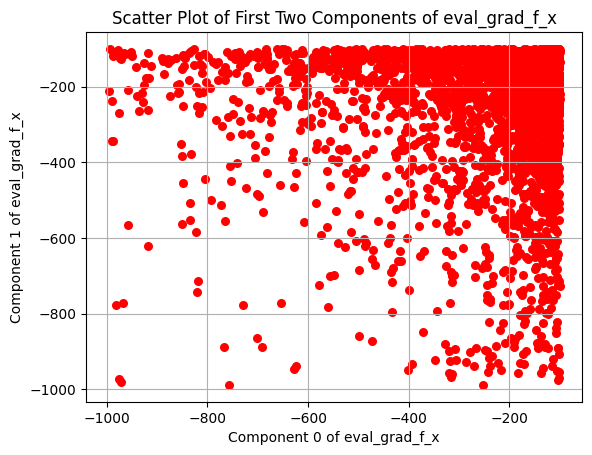

Residual along axis 0 @ value = -549.2078590393066: 1.8667337894439697


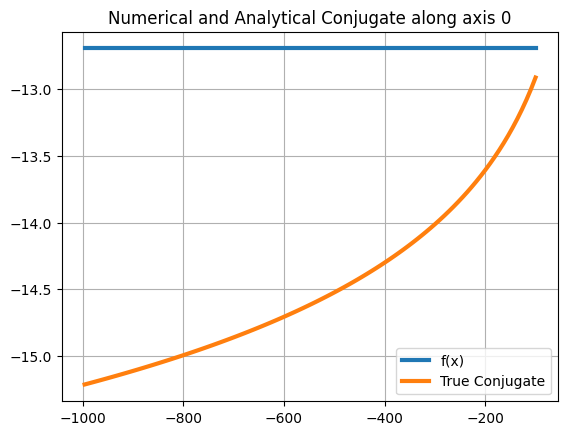

Residual along axis 1 @ value = -549.2078590393066: 1.8667337894439697


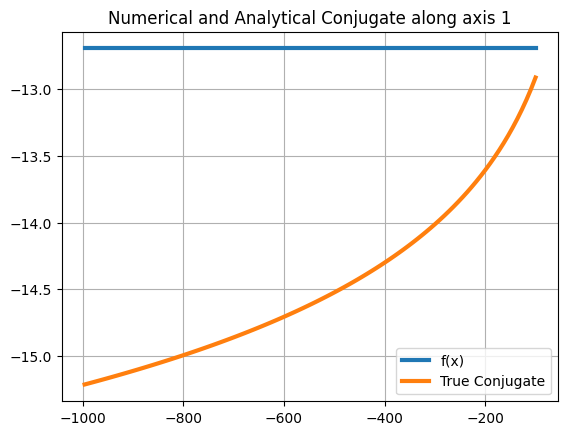

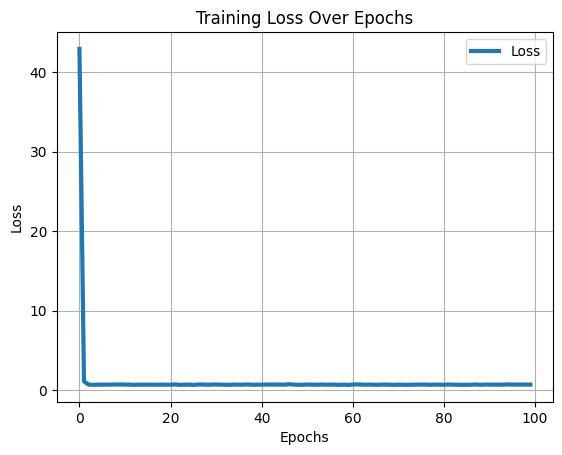

In [ ]:
const_val = (minval + maxval)/2

plot_results(d, eval_grad_f_x, preds, vmap_f_star_true, state, const_val, Loss)


In [ ]:
# loss_list = [float(value) for value in Loss]

# # Print the result
# print(loss_list)

[42.90687561035156, 1.0988155603408813, 0.7029014229774475, 0.6693360805511475, 0.6853675842285156, 0.6948594450950623, 0.6966660618782043, 0.6990774273872375, 0.7085893154144287, 0.7196632027626038, 0.701671838760376, 0.6960172653198242, 0.6679052710533142, 0.7000041604042053, 0.6823346018791199, 0.6878645420074463, 0.6976156234741211, 0.6780000329017639, 0.7005462646484375, 0.6840103268623352, 0.6790996193885803, 0.7279319763183594, 0.663951575756073, 0.6840799450874329, 0.7018827795982361, 0.6597495675086975, 0.7042306065559387, 0.7143151760101318, 0.679911196231842, 0.6972967386245728, 0.719153106212616, 0.6891262531280518, 0.685191810131073, 0.6631247401237488, 0.7093808054924011, 0.680675745010376, 0.6920068264007568, 0.7206954956054688, 0.6774470210075378, 0.686111330986023, 0.6913005113601685, 0.6998770833015442, 0.7134460210800171, 0.7031201124191284, 0.6982960104942322, 0.6885605454444885, 0.7442573308944702, 0.7024441957473755, 0.67014080286026, 0.6862155199050903, 0.7060931

In [ ]:
eval_batch_x, eval_y, eval_grad_f_x = get_next_batch(train_x)
preds = jnp.squeeze(state.apply_fn({'params': state.params}, eval_grad_f_x)).reshape(-1, 1)
accuracy,acc_max, residual, mre = calculate_statistics(eval_batch_x, eval_grad_f_x, preds, vmap_f_star_true, loss_value)
print("Accuracy:", accuracy)
print("Accuracy max norm:", acc_max)
print("Accuracy, rel:", mre)
print("Residual:", residual)

Accuracy: 0.82788366
Accuracy max norm: 3.0729237
Accuracy, rel: 0.052920476
Residual: 0.8321543


In [ ]:
# # run_experiments('folders', base_path=base_path) # to iterate over folders
# run_experiments('configs', config_list=configs)